In [ ]:
import sys
sys.path.append(str(Path('../python_code').resolve()))
import os
import re
import torch
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from torch.utils.data import DataLoader
from DataGenerator import HyperspectralTorchDataset
from SpectralSpatialAttentionModel import SpectralSpatialAttentionModel


# Matplotlib inline for notebooks
%matplotlib inline

Using device: cpu


In [21]:
# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


In [37]:
image_path = Path("../home/ARO.local/collaboration/sagi-tomer-collab/Normalized_Tomato_Seeds/Infected/Tray_1_row_8_column_1.npy")
model_path = Path("../home/ARO.local/collaboration/sagi-tomer-collab/Normalized_Tomato_Seeds/Models/OptimizedModule_0-319-639-bands-1.0-accuracy.pt")
seeds_root = Path("../home/ARO.local/collaboration/sagi-tomer-collab/Normalized_Tomato_Seeds")

In [38]:
# --- Infer Bands and Label ---
model_name = model_path.stem
bands_str = model_name.split("_")[1].split("-bands")[0]
bands = list(map(int, bands_str.split("-")))
label = 0 if "Healthy" in str(image_path) else 1

print(bands, label)

[0, 319, 639] 1


In [39]:
# --- Prepare Image ---
image = np.load(image_path)
height, width = image.shape[:2]
shape = (height, width, len(bands))

In [40]:
dataset = HyperspectralTorchDataset([str(image_path)], [label], bands, shape)
loader = DataLoader(dataset, batch_size=1, shuffle=False)

In [ ]:
# Instantiate model
model = SpectralSpatialAttentionModel(len(bands))
# Load weights before compilation to match keys
state = torch.load(model_path, map_location=device)
# If keys are prefixed with '_orig_mod.', strip that
state = {k.replace("_orig_mod.", ""): v for k, v in state.items()}
model.load_state_dict(state)
# Now compile (optional) and move to device
model = torch.compile(model, backend="eager")
model.to(device).eval()

Inference & extract attentions

In [41]:
with torch.no_grad():
    for x, _ in loader:
        x = x.to(device)
        out = model(x)
        # Unpack outputs
        logits, spec_w, spat_map, fusion_w = out
        break

# Convert to numpy
spec_w = spec_w.squeeze().cpu().numpy()        # (num_bands,)
fusion_w = fusion_w.squeeze().cpu().numpy()    # (fusion_dims,)
input_bands = x.squeeze().cpu().numpy()        # (num_bands, H, W)
# spat_map from model is (1, 1, H, W) or (1, H, W). Extract 2D map:
sp_map = spat_map.cpu().numpy()
# Remove batch and channel dims
if sp_map.ndim == 4:
    heatmap = sp_map[0, 0]
elif sp_map.ndim == 3:
    # either (1, H, W) or (bands, H, W)
    heatmap = sp_map.squeeze(0)
else:
    heatmap = sp_map

In [49]:
print(sp_map.shape)
print(spec_w.shape, heatmap.shape, fusion_w.shape)

(1, 1, 91, 110)
(3,) (91, 110) (6,)


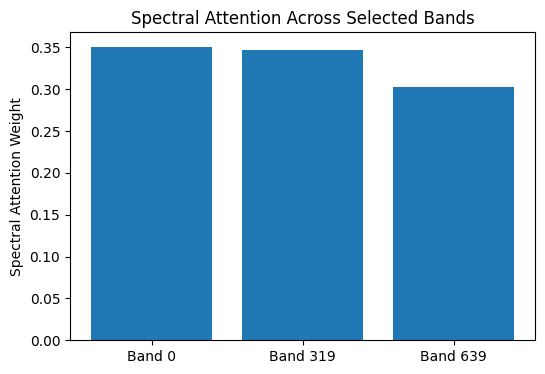

In [43]:
plt.figure(figsize=(6,4))
plt.bar(range(len(spec_w)), spec_w)
plt.xticks(range(len(spec_w)), [f"Band {b}" for b in bands])
plt.ylabel("Spectral Attention Weight")
plt.title("Spectral Attention Across Selected Bands")
plt.show()

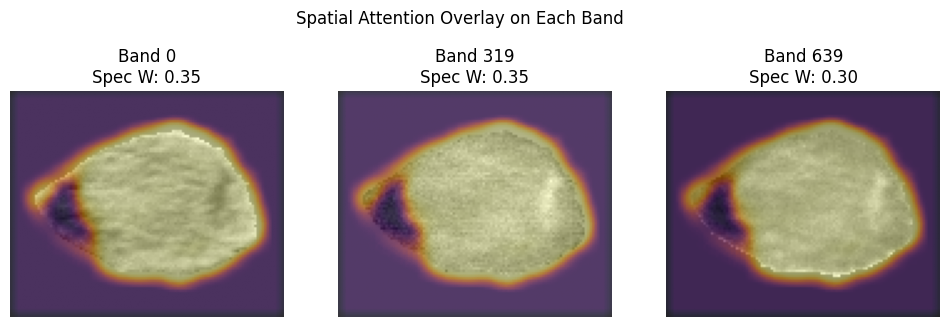

In [44]:
num_bands = len(bands)
fig, axes = plt.subplots(1, num_bands, figsize=(4*num_bands,4))
for i in range(num_bands):
    axes[i].imshow(input_bands[i], cmap='gray')
    axes[i].imshow(heatmap, cmap='inferno', alpha=0.5)
    axes[i].set_title(f"Band {bands[i]}\nSpec W: {spec_w[i]:.2f}")
    axes[i].axis('off')
plt.suptitle("Spatial Attention Overlay on Each Band")
plt.show()

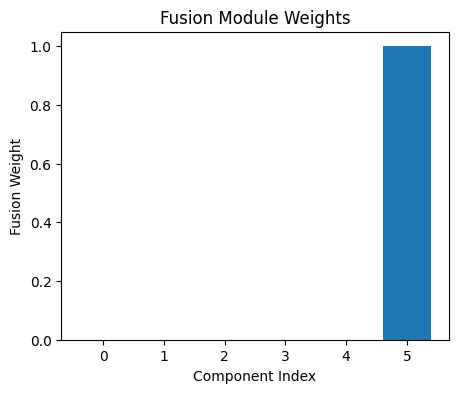

In [45]:
plt.figure(figsize=(5,4))
plt.bar(range(len(fusion_w)), fusion_w)
plt.xlabel("Component Index")
plt.ylabel("Fusion Weight")
plt.title("Fusion Module Weights")
plt.show()

In [46]:
prob = torch.sigmoid(logits).item()
pred = int(prob > 0.5)
print(f"Logits: {logits.item():.4f}, Probability: {prob:.4f}")
print("Predicted:", "Infected" if pred else "Healthy")

Logits: 8.8977, Probability: 0.9999
Predicted: Infected
